✅  Artifacts loaded.
    Models        : ['Decision Tree', 'Logistic Regression', 'Gradient Boosting']
    Test samples  : 79
    Features      : ['avg_grade', 'G2', 'Fedu', 'paid', 'absences', 'G1', 'Fjob', 'famsize', 'Dalc', 'reason']

  7.1  PERFORMANCE METRICS
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Decision Tree          0.8608     0.7727  0.7391    0.7556   0.9503
Logistic Regression    0.8987     0.8000  0.8696    0.8333   0.9534
Gradient Boosting      0.8608     0.8000  0.6957    0.7442   0.9534

  🏆  Best model by F1-Score: Logistic Regression  (0.8333)

  7.2  MODEL COMPARISON CHART


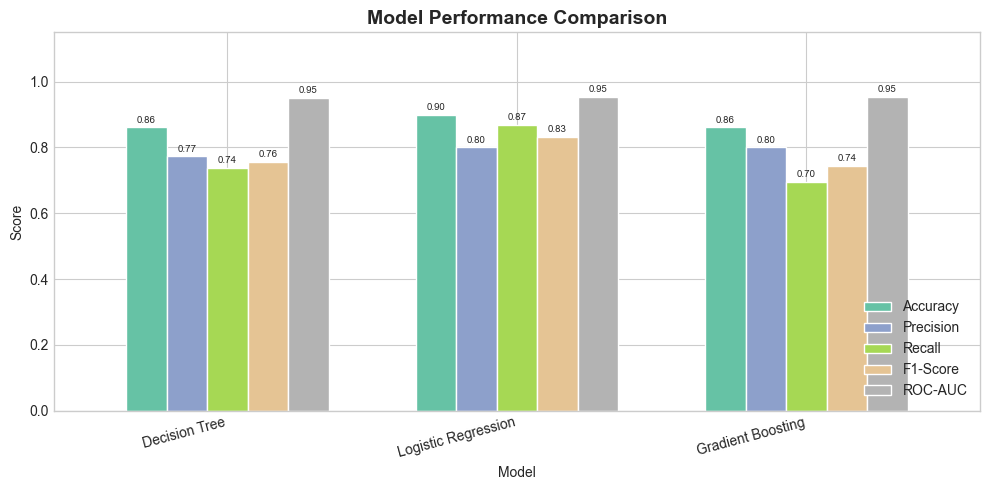

  Plot saved → ../docs/model_comparison.png

  7.3  CONFUSION MATRICES


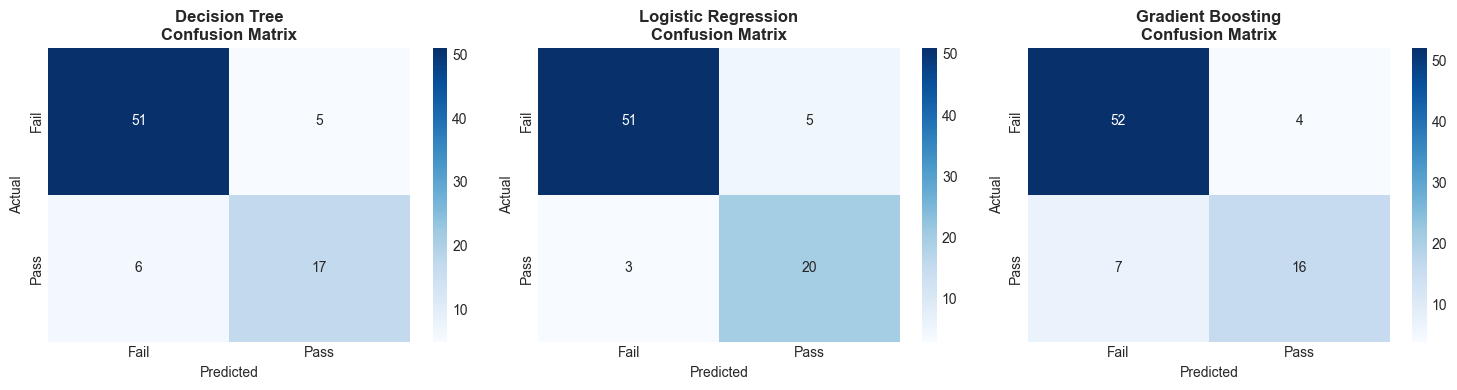

  Plot saved → ../docs/confusion_matrices.png

  7.4  ROC CURVES


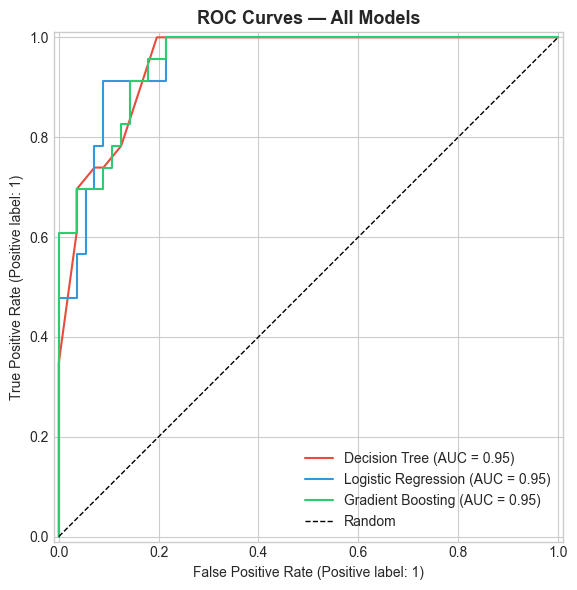

  Plot saved → ../docs/roc_curves.png

  7.5  5-FOLD STRATIFIED CROSS-VALIDATION (F1 Score)
  Decision Tree              Mean=0.8294  Std=0.1292  Scores=[0.889 0.889 0.909 0.571 0.889]
  Logistic Regression        Mean=0.7544  Std=0.0844  Scores=[0.667 0.667 0.8   0.75  0.889]
  Gradient Boosting          Mean=0.7161  Std=0.1216  Scores=[0.6   0.571 0.909 0.75  0.75 ]

  7.6  CLASSIFICATION REPORTS

  ── Decision Tree ──
              precision    recall  f1-score   support

        Fail       0.89      0.91      0.90        56
        Pass       0.77      0.74      0.76        23

    accuracy                           0.86        79
   macro avg       0.83      0.82      0.83        79
weighted avg       0.86      0.86      0.86        79


  ── Logistic Regression ──
              precision    recall  f1-score   support

        Fail       0.94      0.91      0.93        56
        Pass       0.80      0.87      0.83        23

    accuracy                           0.90        79
 

In [1]:
# =============================================================================
# STAGE 7 — Model Evaluation & Comparison
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage7_evaluation.py   (after stage6)
# Input  : ../models/trained_models.pkl
#          ../data/test_set.csv
# Output : plots saved to ../docs/
# =============================================================================

import os
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

DOCS_DIR = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)


# ── Load models and test data ─────────────────────────────────────────────────
def load_artifacts():
    required = {
        "../models/trained_models.pkl" : "trained_models.pkl",
        "../data/test_set.csv"         : "test_set.csv",
        "../models/selected_features.pkl": "selected_features.pkl",
    }
    for path, name in required.items():
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{name} not found.\n"
                "Please run stage6_model_building.py first."
            )

    trained_models    = joblib.load("../models/trained_models.pkl")
    selected_features = joblib.load("../models/selected_features.pkl")
    test_df  = pd.read_csv("../data/test_set.csv")
    X_test   = test_df[selected_features].values
    y_test   = test_df["pass"].values

    print("✅  Artifacts loaded.")
    print(f"    Models        : {list(trained_models.keys())}")
    print(f"    Test samples  : {len(y_test)}")
    print(f"    Features      : {selected_features}\n")
    return trained_models, X_test, y_test, selected_features


# ── 7.1  Metrics Table ────────────────────────────────────────────────────────
def compute_metrics(trained_models, X_test, y_test):
    print("=" * 60)
    print("  7.1  PERFORMANCE METRICS")
    print("=" * 60)

    records = []
    for name, model in trained_models.items():
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        records.append({
            "Model"    : name,
            "Accuracy" : accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall"   : recall_score(y_test, y_pred),
            "F1-Score" : f1_score(y_test, y_pred),
            "ROC-AUC"  : roc_auc_score(y_test, y_proba),
        })

    results_df = pd.DataFrame(records).set_index("Model")
    print(results_df.round(4).to_string())

    best = results_df["F1-Score"].idxmax()
    print(f"\n  🏆  Best model by F1-Score: {best}  "
          f"({results_df.loc[best,'F1-Score']:.4f})")
    return results_df


# ── 7.2  Bar Chart Comparison ─────────────────────────────────────────────────
def plot_metrics_comparison(results_df):
    print("\n" + "=" * 60)
    print("  7.2  MODEL COMPARISON CHART")
    print("=" * 60)
    fig, ax = plt.subplots(figsize=(10, 5))
    results_df.plot(kind="bar", ax=ax, width=0.7,
                    colormap="Set2", edgecolor="white")
    ax.set_title("Model Performance Comparison",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.legend(loc="lower right")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
    plt.tight_layout()
    out = f"{DOCS_DIR}/model_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")


# ── 7.3  Confusion Matrices ───────────────────────────────────────────────────
def plot_confusion_matrices(trained_models, X_test, y_test):
    print("\n" + "=" * 60)
    print("  7.3  CONFUSION MATRICES")
    print("=" * 60)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, model) in zip(axes, trained_models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Fail","Pass"],
                    yticklabels=["Fail","Pass"])
        ax.set_title(f"{name}\nConfusion Matrix", fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    out = f"{DOCS_DIR}/confusion_matrices.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")


# ── 7.4  ROC Curves ───────────────────────────────────────────────────────────
def plot_roc_curves(trained_models, X_test, y_test):
    print("\n" + "=" * 60)
    print("  7.4  ROC CURVES")
    print("=" * 60)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#e74c3c", "#3498db", "#2ecc71"]
    for (name, model), color in zip(trained_models.items(), colors):
        RocCurveDisplay.from_estimator(
            model, X_test, y_test, ax=ax, name=name, color=color
        )
    ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random")
    ax.set_title("ROC Curves — All Models",
                 fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    out = f"{DOCS_DIR}/roc_curves.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")


# ── 7.5  Cross-Validation ─────────────────────────────────────────────────────
def cross_validate_models(trained_models, X_test, y_test):
    print("\n" + "=" * 60)
    print("  7.5  5-FOLD STRATIFIED CROSS-VALIDATION (F1 Score)")
    print("=" * 60)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for name, model in trained_models.items():
        scores = cross_val_score(model, X_test, y_test,
                                 cv=cv, scoring="f1")
        print(f"  {name:<25}  "
              f"Mean={scores.mean():.4f}  Std={scores.std():.4f}  "
              f"Scores={scores.round(3)}")


# ── 7.6  Classification Report ────────────────────────────────────────────────
def print_classification_reports(trained_models, X_test, y_test):
    print("\n" + "=" * 60)
    print("  7.6  CLASSIFICATION REPORTS")
    print("=" * 60)
    for name, model in trained_models.items():
        y_pred = model.predict(X_test)
        print(f"\n  ── {name} ──")
        print(classification_report(y_test, y_pred,
                                    target_names=["Fail","Pass"]))


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    trained_models, X_test, y_test, selected_features = load_artifacts()
    results_df = compute_metrics(trained_models, X_test, y_test)
    plot_metrics_comparison(results_df)
    plot_confusion_matrices(trained_models, X_test, y_test)
    plot_roc_curves(trained_models, X_test, y_test)
    cross_validate_models(trained_models, X_test, y_test)
    print_classification_reports(trained_models, X_test, y_test)

    # Save results for Stage 10 summary
    results_df.to_csv("../data/evaluation_results.csv")

    print(f"\n✅  Stage 7 complete. All evaluation plots saved to {DOCS_DIR}/")
    print("    Next  : python stage8_explainability.py  (Abhi)")
